In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
import mplhep as hep

In [2]:
# client = scaleout.make_dask_client("tls://localhost:8786")
# client

from distributed import LocalCluster, Client

cluster = LocalCluster()
cluster.scale(4)  # create 4 local workers
client = Client(cluster)


In [5]:
print(client)

<Client: 'tcp://127.0.0.1:38861' processes=4 threads=24, memory=46.53 GiB>


In [6]:
samples = [
    '2Mu2E_500GeV_0p25GeV_4p0mm',
     '2Mu2E_500GeV_1p2GeV_19p0mm',
     '2Mu2E_500GeV_5p0GeV_80p0mm',
  
]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="signal_2mu2e_v10.yaml",
                                  # max_files =10
                                  # max_files =1
                                 replace_xcache = True
                                )

In [7]:
channels = [
    "baseNoLj_A_ee_lowLxyA",
    "baseNoLj_A_ee_matched_lj_lowLxyA",
    "baseNoLj_A_ee_matched_lj_lowLxyA_iso",
    "baseNoLj_A_ee_matched_lj_lowLxyA_iso_disp", 

 
    
           
           ]
p = sidm_processor.SidmProcessor(
    channels,
    ["genA_toE_effi_base",],
    unweighted_hist=False,
   
)
runner = processor.Runner(
    # executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)
# test if processor is serializable
output = runner.run(fileset, treename="Events", processor_instance=p)




[                                        ] | 0% Completed |  8.0s3s

/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


[                                        ] | 0% Completed |  8.9s

/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


[                                        ] | 0% Completed |  9.3s

...

[#                                       ] | 3% Completed |  2min 19.5s

/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


[###                                     ] | 8% Completed |  2min 36.1s

/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/home/mariaj-cern/.local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


[################                        ] | 40% Completed |  7min 19.6sWarning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'
[################                        ] | 41% Completed |  7min 31.7sWarning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'
[################                        ] | 42% Completed |  7min 34.3sWarning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'
[####################                    ] | 51% Completed |  7min 56.5sWarning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'
2Mu2E_500GeV_0p25GeV_4p0mm is simulation. Scaling histograms or cutflows according to lumi*xs._matched_muons'
Ignoring signal cross sections, assuming 1 fb
2Mu2E_500GeV_5p0GeV_80p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Ignoring signal cross

/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered 

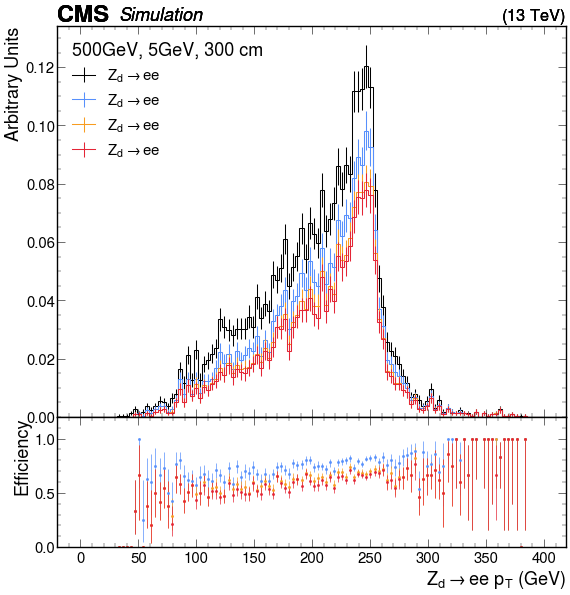

In [9]:
hists = output["out"]["2Mu2E_500GeV_5p0GeV_80p0mm"]["hists"]

ch1 = "baseNoLj_A_ee_lowLxyA"
ch2 = "baseNoLj_A_ee_matched_lj_lowLxyA"
ch3 = "baseNoLj_A_ee_matched_lj_lowLxyA_iso"
ch4 = "baseNoLj_A_ee_matched_lj_lowLxyA_iso_disp"

legend = [
r"$Z_d \rightarrow ee$ ",
r"$Z_d \rightarrow ee$ with $e \gamma$ LJ ",
r"$Z_d \rightarrow ee$ with $e \gamma$ LJ Iso",
r"$Z_d \rightarrow ee$ with $e \gamma$ LJ Iso and Disp"
]

histogram = "genAs_toE_pt_highRange"

num_list = [
          hists[histogram][ch2, :400j],
          hists[histogram][ch3, :400j],
         hists[histogram][ch4, :400j],
]
den = hists[histogram][ch1,:400j]
utilities.plot_ratio (num_list,den,legend =legend, text = "500GeV, 5GeV, 300 cm", ylabel = "Arbitrary Units")
folder_name = "plots/"
file_name = "2Mu2E_500GeV_5p0GeV_80p0mm" + histogram
save_path = os.path.join(folder_name, file_name )   
plt.savefig(save_path)


/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered 

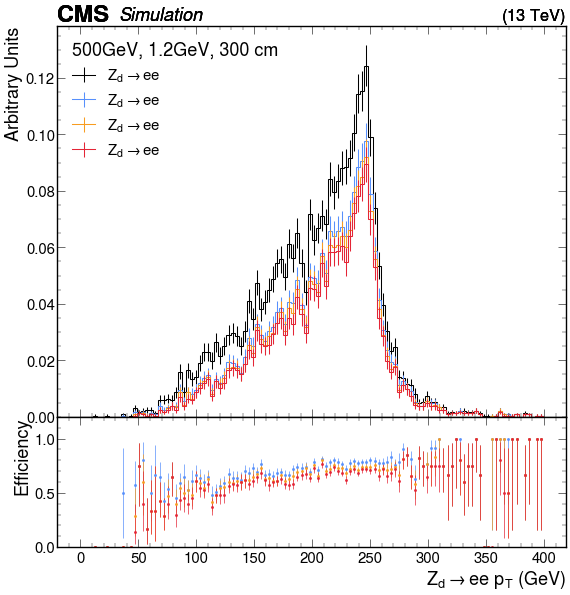

In [10]:
hists = output["out"]["2Mu2E_500GeV_1p2GeV_19p0mm"]["hists"]


histogram = "genAs_toE_pt_highRange"

num_list = [
          hists[histogram][ch2, :400j],
          hists[histogram][ch3, :400j],
         hists[histogram][ch4, :400j],
]
den = hists[histogram][ch1,:400j]
utilities.plot_ratio (num_list,den,legend =legend, text = "500GeV, 1.2GeV, 300 cm", ylabel = "Arbitrary Units")  

folder_name = "plots/"
file_name = "2Mu2E_500GeV_1p2GeV_19p0mm" + histogram
save_path = os.path.join(folder_name, file_name)
plt.savefig(save_path)

/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:195: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:196: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/mariaj-cern/SIDM/sidm/tools/utilities.py:190: RuntimeWarning: invalid value encountered 

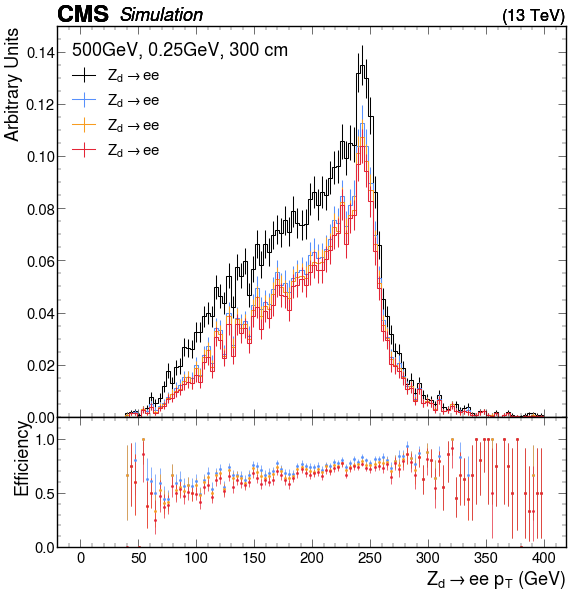

In [11]:
hists = output["out"]["2Mu2E_500GeV_0p25GeV_4p0mm"]["hists"]


histogram = "genAs_toE_pt_highRange"

num_list = [
          hists[histogram][ch2, :400j],
          hists[histogram][ch3, :400j],
         hists[histogram][ch4, :400j],
]
den = hists[histogram][ch1,:400j]
utilities.plot_ratio (num_list,den,legend =legend, text = "500GeV, 0.25GeV, 300 cm", ylabel = "Arbitrary Units") 

folder_name = "plots/"
file_name = "2Mu2E_500GeV_0p25GeV_4p0mm" + histogram
save_path = os.path.join(folder_name, file_name)
plt.savefig(save_path)